In [1]:
#!pip install keras_cv tensorflow_io

In [1]:
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras import Model
import os
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

# from google.colab import drive, files
# drive.mount('/content/drive')

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', None)
pd.set_option('display.float_format', '{:.2f}'.format)
pd.set_option('display.max_colwidth', None)

In [2]:
# !cp -r "/content/drive/MyDrive/model" /content/
# !cp -r "/content/drive/MyDrive/Test" /content/
# !cp -r "/content/drive/MyDrive/images_test/images_spectograms" /content/

In [3]:
from src.model_trainer import ModelTrainer

model_name = "ResNet152V2" #"MobileNetV3Large" #"EfficientNetV2L" #"ResNet152V2" #"EfficientNetB7"

model_trainer = ModelTrainer(
    model_name=model_name,
    img_shape=(128, 256, 1),
    n_classes=667,
    dropout_rate=0.2,
    label_smoothing=0.1,
    fine_tune_layers=200
)

model = model_trainer.create_model()
model.summary()
model.load_weights(f"./models/weights_{model_name}.weights.h5")
tf.keras.backend.clear_session()

Model: "ResNet152V2_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 256, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ (None, 128, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ preprocess_input (Lambda)       │ (None, 128, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet152v2 (Functional)        │ (None, 2048)           │    58,331,648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ top_dropout (Dropout)           │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ logits (Dense)                  │ (None, 667)            │     1,366,683 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 59,698,331 (227.73 MB)

 Trainable params: 32,846,491 (125.30 MB)

 Non-trainable params: 26,851,840 (102.43 MB)

/Users/camcortes/Documents/birds-sounds/.venv-birds-song/lib/python3.11/site-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 368 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [4]:
# cargar el label encoder del pickle
import pickle

with open(f'./models/label_encoder_{model_name}.pkl', 'rb') as f:
    label_encoder = pickle.load(f)

In [5]:
from src.image_preprocessor import ImagePreprocessor

preprocessor = ImagePreprocessor(label_encoder=label_encoder)
data = preprocessor.load_data_from_directory("src/data/images_test/images_spectograms")
data.head()

/Users/camcortes/Documents/birds-sounds/.venv-birds-song/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,label,image_path
0,Acropternis orthonyx,src/data/images_test/images_spectograms/Acropternis orthonyx/121142_13.jpeg
1,Acropternis orthonyx,src/data/images_test/images_spectograms/Acropternis orthonyx/511703_5.jpeg
2,Acropternis orthonyx,src/data/images_test/images_spectograms/Acropternis orthonyx/461011_0.jpeg
3,Acropternis orthonyx,src/data/images_test/images_spectograms/Acropternis orthonyx/621780_9.jpeg
4,Acropternis orthonyx,src/data/images_test/images_spectograms/Acropternis orthonyx/428484_0.jpeg


In [6]:
sp_metrics = pd.read_csv("models/metrics_resnet.csv")

In [7]:
def cargar_imagen_redimensionada(ruta_imagen, ancho=224, alto=224):
    datos_imagen = tf.io.read_file(ruta_imagen)
    imagen = tf.io.decode_jpeg(datos_imagen)
    imagen = tf.image.resize(imagen, [alto, ancho])
    imagen = tf.cast(imagen, tf.float32)
    return imagen

def graficar_imagen(ruta_imagen, titulo=None, guardar_en=None, figsize=(4, 7)):
    try:
        imagen = cargar_imagen_redimensionada(ruta_imagen)
    except Exception as e:
        print(f"Error al cargar la imagen: {e}")
        return None
    fig, ax = plt.subplots(figsize=figsize)
    ax.imshow(imagen.numpy().astype(np.uint8))
    if titulo is None:
        titulo = f"Imagen: {os.path.basename(ruta_imagen)}"
    ax.set_title(titulo)
    ax.axis('off')
    if guardar_en:
        plt.savefig(guardar_en, dpi=300, bbox_inches='tight')
        print(f"Imagen guardada en: {guardar_en}")

    plt.tight_layout()
    plt.show()

In [8]:
import random
from tqdm import tqdm

def especie_batch(data):
    species = list(set(data["label"]))
    num_species = len(species)
    for i, specie in enumerate(tqdm(species, desc=f"Especies procesadas")):
        print(f"\nEspecie {i+1} de {(num_species)}, ({specie})")
        yield specie

def specie_ds(data, gen):
    try:
        specie = next(gen)
        df = data[data["label"] == specie]
        if df.empty:
            print(f"No more species")
            return None, None
    except StopIteration:
        return None, None
    return specie, preprocessor.create_validation_dataset(df)

In [9]:
def calcular_incertidumbre(dataset_espectrogramas, modelo):
    predicciones_mc = []
    confianzas_mc = []
    etiqueta_real_lista =[]
    etiqueta_inferencia_lista = []
    probabilidades_todas = []  # Lista para almacenar todas las probabilidades

    if dataset_espectrogramas:
        for imagenes_batch, etiquetas_batch in dataset_espectrogramas.take(1):

            imagen = imagenes_batch[0]
            imagen_batch = tf.expand_dims(imagen, axis=0)
            etiqueta_real = tf.argmax(etiquetas_batch[0])
            etiqueta_real_lista.append(etiqueta_real.numpy())
            # Predicción convencional (sin dropout activo)
            logits_inferencia = modelo(imagen_batch, training=False)
            #logits_inferencia = modelo.predict(imagen_batch)
            probabilidades_inferencia = tf.nn.softmax(logits_inferencia, axis=-1).numpy()
            clase_predicha_inferencia = np.argmax(probabilidades_inferencia, axis=-1)[0]
            etiqueta_inferencia_lista.append(clase_predicha_inferencia)

            # MONTE CARLO DROPOUT: Múltiples pasadas con training=True
            for _ in range(1000):
                logits = modelo(imagen_batch, training=True)
                probabilidades = tf.nn.softmax(logits, axis=-1).numpy()
                probabilidades_todas.append(probabilidades[0])  # Guardamos todas las probabilidades
                clase_predicha = np.argmax(probabilidades, axis=-1)[0]
                confianza = probabilidades[0, clase_predicha]

                predicciones_mc.append(clase_predicha)
                confianzas_mc.append(confianza)

    # Calcular la entropía si hay datos disponibles
    entropia = 0
    if probabilidades_todas:
        # Calculamos la entropía promedio
        probabilidades_array = np.array(probabilidades_todas)
        prob_media = np.mean(probabilidades_array, axis=0)
        entropia = -np.sum(prob_media * np.log(prob_media + 1e-9))

    return predicciones_mc, confianzas_mc, etiqueta_inferencia_lista, etiqueta_real_lista, entropia

In [10]:
def crear_dataframe_incertidumbre(data, muestra, modelo):
    # Generar dataset de especies
    dataset_generado = especie_batch(muestra)

    # Recolectar resultados de cada especie
    resultados = {}
    for i in range(data["label"].nunique()):
        especie, dataset_especie = specie_ds(data, dataset_generado)
        if especie is None:
            break

        predicciones_mc, confianzas_mc, clase_predicha_inferencia, etiqueta_real, entropia = calcular_incertidumbre(dataset_especie, modelo)
        resultados[especie] = {
            "clase_real": etiqueta_real,
            "clase_predicha_inferencia": clase_predicha_inferencia,
            "predicciones_mc": predicciones_mc,
            "confianzas_mc": confianzas_mc,
            "entropia": entropia
        }

    # Procesar resultados para crear el dataframe final
    filas = []
    for especie, datos in resultados.items():
        clase_real = datos["clase_real"]  # Lista de etiquetas reales
        clase_predicha = datos["clase_predicha_inferencia"]  # Lista de predicciones normales
        predicciones = datos["predicciones_mc"]  # Lista de predicciones Monte Carlo
        confianzas = datos["confianzas_mc"]  # Lista de confianzas
        entropia = datos["entropia"]

        # Para cada predicción Monte Carlo
        for i in range(len(predicciones)):
            # Etiqueta real debe ser consistente para todas las filas de la misma imagen
            etiqueta_real = clase_real[0] if len(clase_real) > 0 else None
            # Clase predicha normal (solo una por imagen)
            etiqueta_pred = clase_predicha[0] if len(clase_predicha) > 0 else None

            filas.append({
                "especie": especie,
                "clase_real": etiqueta_real,
                "clase_predicha": etiqueta_pred,
                "prediccion_mc": predicciones[i],
                "confianza_mc": confianzas[i] if i < len(confianzas) else None,
                # Comparación correcta de valores individuales, no listas
                'true_positive': 1 if etiqueta_real == etiqueta_pred else 0,
                'true_positivo_mc': 1 if etiqueta_real == predicciones[i] else 0,
                "entropia": entropia
            })

    return pd.DataFrame(filas)

In [11]:
def plot_incertidumbres(especie_df, label, title):
    plt.figure(figsize=(7, 4))
    sns.set_theme(style="white")

    # Crear un array con los colores - rojo para todas las barras
    colores = ['#FF4136'] * len(especie_df)  # Color rojo para todas las barras

    especie_df = especie_df.sort_values(by="prediccion_mc", ascending=True).reset_index(drop=True)
    indice_label = especie_df[especie_df['prediccion_mc'] == label].index

    for idx in indice_label:
        colores[idx] = '#2ECC40'  # Color verde para las barras con label 300

    # Crear el gráfico con los colores personalizados
    ax = sns.barplot(
        x=especie_df['prediccion_mc'],
        y=especie_df["proportion"],
        palette=colores,  # Usar la lista de colores personalizada
        edgecolor="black",
        linewidth=0.8
    )

    # Añadir título y etiquetas
    plt.title(f'Distribución de predicciones para {title}',
            fontsize=16, fontweight='bold', pad=20)
    plt.xlabel('Clase predicha', fontsize=12)
    plt.ylabel('Proporción', fontsize=12)

    # Mejorar la cuadrícula
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    # Añadir valores sobre las barras principales
    for i, p in enumerate(ax.patches):
        height = p.get_height()
        height_100 = height * 100
        if height > 0:
            ax.text(p.get_x() + p.get_width()/2., height + 0.01,
                    f'{height_100:.1f}%', ha="center", fontsize=10)

    plt.ylim(0,1)

    # Eliminar líneas del marco excepto abajo y a la izquierda
    sns.despine()
    plt.tight_layout()
    plt.show()

In [12]:
sp = data[data["label"] == "Lathrotriccus euleri"]
sp

,label,image_path
14644,Lathrotriccus euleri,src/data/images_test/images_spectograms/Lathrotriccus euleri/30482_2.jpeg
14645,Lathrotriccus euleri,src/data/images_test/images_spectograms/Lathrotriccus euleri/206677_15.jpeg
14646,Lathrotriccus euleri,src/data/images_test/images_spectograms/Lathrotriccus euleri/390420_3.jpeg
14647,Lathrotriccus euleri,src/data/images_test/images_spectograms/Lathrotriccus euleri/332605_1.jpeg
14648,Lathrotriccus euleri,src/data/images_test/images_spectograms/Lathrotriccus euleri/17401_7.jpeg
14649,Lathrotriccus euleri,src/data/images_test/images_spectograms/Lathrotriccus euleri/95632_8.jpeg
14650,Lathrotriccus euleri,src/data/images_test/images_spectograms/Lathrotriccus euleri/614931_8.jpeg
14651,Lathrotriccus euleri,src/data/images_test/images_spectograms/Lathrotriccus euleri/414197_3.jpeg
14652,Lathrotriccus euleri,src/data/images_test/images_spectograms/Lathrotriccus euleri/37941_8.jpeg
14653,Lathrotriccus euleri,src/data/images_test/images_spectograms/Lathrotriccus euleri/258871_0.jpeg


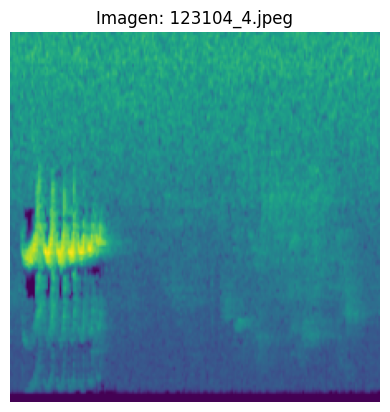

In [14]:
graficar_imagen(sp['image_path'].iloc[32])

In [61]:
def plot_combinado(ruta_imagen, especie_df, label, titulo_especie, figsize=(12, 5)):
    """
    Crea una visualización combinada con la imagen y el gráfico de incertidumbres lado a lado.

    Args:
        ruta_imagen: Ruta a la imagen a cargar
        especie_df: DataFrame con datos de predicciones para la especie
        label: Label de la clase correcta
        titulo_especie: Nombre de la especie para los títulos
        figsize: Tamaño de la figura completa (ancho, alto)
    """
    # Crear figura con dos subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)

    # Primer subplot: Mostrar imagen
    try:
        imagen = cargar_imagen_redimensionada(ruta_imagen)
        ax1.imshow(imagen.numpy().astype(np.uint8))
        ax1.set_title(f"Spectogram: {titulo_especie}")
        ax1.axis('off')
    except Exception as e:
        print(f"Error al cargar la imagen: {e}")
        ax1.text(0.5, 0.5, "Error al cargar la imagen",
                 ha='center', va='center')
        ax1.axis('off')

    # Segundo subplot: Gráfico de incertidumbres
    plt.sca(ax2)  # Establecer ax2 como el eje activo

    # Ordenar datos
    especie_df = especie_df.sort_values(by="prediccion_mc", ascending=True).reset_index(drop=True)

    # Crear colores personalizados
    colores = ['#FF4136'] * len(especie_df)  # Color rojo para todas las barras
    indice_label = especie_df[especie_df['prediccion_mc'] == label].index
    for idx in indice_label:
        colores[idx] = '#2ECC40'  # Color verde para las barras con label correcto

    # Crear el gráfico de barras
    sns.barplot(
        x=especie_df['prediccion_mc'],
        y=especie_df["proportion"],
        palette=colores,
        edgecolor="black",
        linewidth=0.8,
        ax=ax2
    )

    # Configurar el gráfico de incertidumbres
    ax2.set_title(f'Distribución de predicciones para {titulo_especie}',
                fontsize=12, fontweight='bold', pad=10)
    ax2.set_xlabel('Clase predicha', fontsize=10)
    ax2.set_ylabel('Proporción', fontsize=10)
    ax2.grid(axis='y', linestyle='--', alpha=0.7)

    # Añadir valores sobre las barras
    for i, p in enumerate(ax2.patches):
        height = p.get_height()
        height_100 = height * 100
        if height > 0:
            ax2.text(p.get_x() + p.get_width()/2., height + 0.01,
                    f'{height_100:.1f}%', ha="center", fontsize=9)

    ax2.set_ylim(0, 1)

    # Eliminar líneas del marco excepto abajo y a la izquierda
    sns.despine(ax=ax2)

    plt.tight_layout()
    plt.show()

# **Volatinia jacarina**

In [21]:
sp = data[data["label"] == "Volatinia jacarina"]
muestra = sp[sp['image_path'].str.contains('146774_0.jpeg')]
muestra

,label,image_path
31431,Volatinia jacarina,src/data/images_test/images_spectograms/Volatinia jacarina/146774_0.jpeg


In [22]:
df_final = crear_dataframe_incertidumbre(data, muestra, model)
df_final.head()


Especie 1 de 1, (Volatinia jacarina)


Especies procesadas:   0%|          | 0/1 [00:32<?, ?it/s]
2025-04-21 19:31:29.992360: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
Especies procesadas: 100%|██████████| 1/1 [06:12<00:00, 372.06s/it]


,especie,clase_real,clase_predicha,prediccion_mc,confianza_mc,true_positive,true_positivo_mc,entropia
0,Volatinia jacarina,651,651,298,0.01,1,0,6.44
1,Volatinia jacarina,651,651,651,0.01,1,1,6.44
2,Volatinia jacarina,651,651,651,0.01,1,1,6.44
3,Volatinia jacarina,651,651,651,0.01,1,1,6.44
4,Volatinia jacarina,651,651,651,0.01,1,1,6.44


In [23]:
Volatinia_jacarina = df_final['prediccion_mc'].\
    value_counts(normalize=True).reset_index().\
    sort_values(by='proportion', ascending=False).head(10)

In [24]:
Volatinia_jacarina

,prediccion_mc,proportion
0,651,0.91
1,114,0.05
2,298,0.01
3,205,0.01
4,17,0.00
5,464,0.00
6,547,0.00
7,65,0.00
8,554,0.00
9,97,0.00


/var/folders/_1/9ctwy_pn6bv2hyw11l_gqhm9855lbl/T/ipykernel_18150/3577632967.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


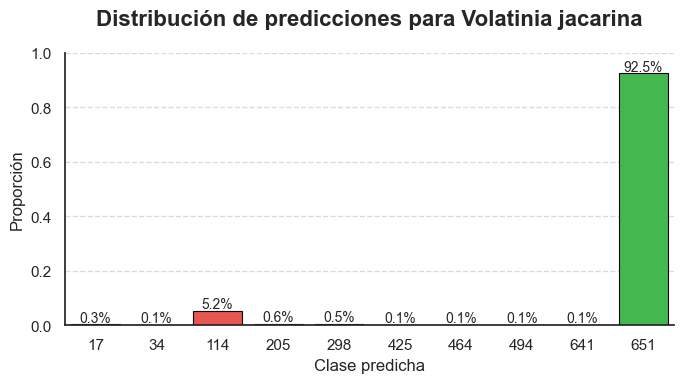

In [32]:
plot_incertidumbres(Volatinia_jacarina, 651, "Volatinia jacarina")

/var/folders/_1/9ctwy_pn6bv2hyw11l_gqhm9855lbl/T/ipykernel_26938/2430494145.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


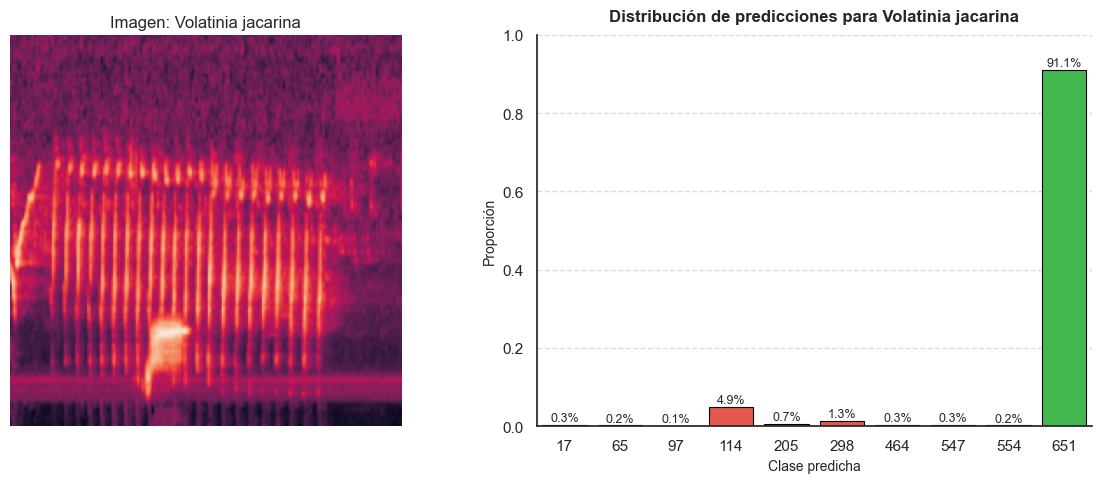

In [ ]:
plot_combinado(
    ruta_imagen=sp['image_path'].iloc[1],
    especie_df=Volatinia_jacarina,
    label=651,
    titulo_especie="Volatinia jacarina"
)

# **Legatus leucophaius**

In [41]:
sp = data[data["label"] == "Legatus leucophaius"]
muestra = sp[sp['image_path'].str.contains('275478_4.jpeg')]
muestra

,label,image_path
14744,Legatus leucophaius,src/data/images_test/images_spectograms/Legatus leucophaius/275478_4.jpeg


In [42]:
df_final = crear_dataframe_incertidumbre(data, muestra, model)
df_final.head()

Especies procesadas:   0%|          | 0/1 [00:00<?, ?it/s]


Especie 1 de 1, (Legatus leucophaius)


2025-04-21 19:58:17.591461: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
Especies procesadas: 100%|██████████| 1/1 [06:15<00:00, 375.73s/it]


,especie,clase_real,clase_predicha,prediccion_mc,confianza_mc,true_positive,true_positivo_mc,entropia
0,Legatus leucophaius,301,508,301,0.00,0,1,6.46
1,Legatus leucophaius,301,508,214,0.00,0,0,6.46
2,Legatus leucophaius,301,508,243,0.01,0,0,6.46
3,Legatus leucophaius,301,508,608,0.00,0,0,6.46
4,Legatus leucophaius,301,508,301,0.01,0,1,6.46


In [43]:
Legatus_leucophaius = df_final['prediccion_mc'].\
    value_counts(normalize=True).reset_index().\
    sort_values(by='proportion', ascending=False).head(10)

In [44]:
Legatus_leucophaius

,prediccion_mc,proportion
0,301,0.43
1,128,0.13
2,344,0.08
3,641,0.04
4,204,0.03
5,214,0.03
6,243,0.02
7,99,0.02
8,127,0.02
9,63,0.01


/var/folders/_1/9ctwy_pn6bv2hyw11l_gqhm9855lbl/T/ipykernel_26938/3577632967.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


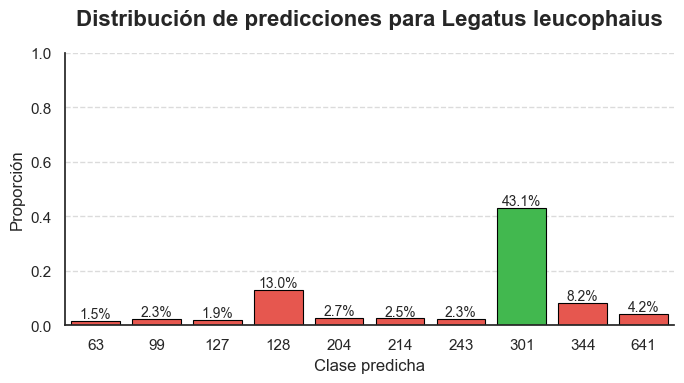

In [45]:
plot_incertidumbres(Legatus_leucophaius, 301, "Legatus leucophaius")

/var/folders/_1/9ctwy_pn6bv2hyw11l_gqhm9855lbl/T/ipykernel_26938/3535191964.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


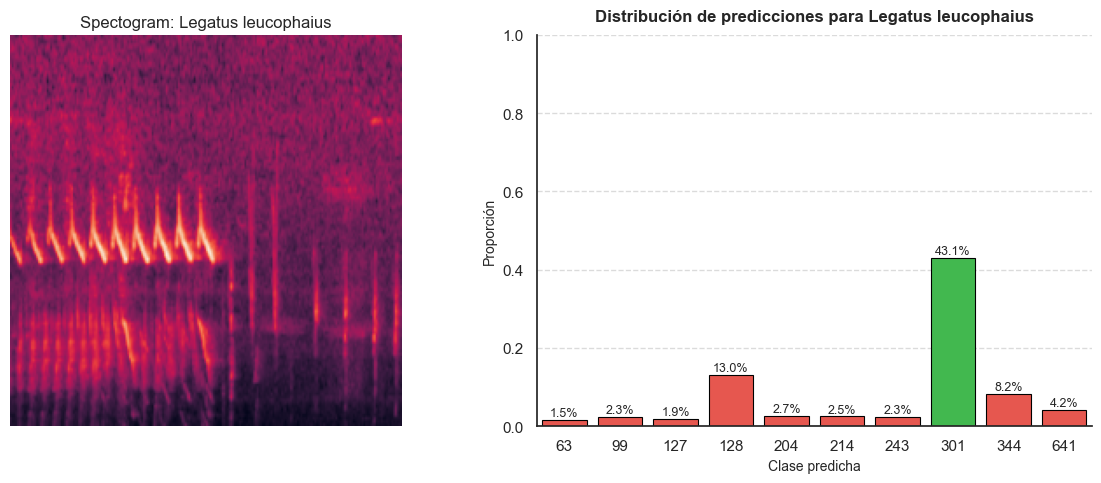

In [72]:
plot_combinado(
    ruta_imagen=sp['image_path'].iloc[0],
    especie_df=Legatus_leucophaius,
    label=301,
    titulo_especie="Legatus leucophaius"
)

# **Hylophilus thoracicus**

In [96]:
sp = data[data["label"] == "Hylophilus thoracicus"]
muestra = sp[sp['image_path'].str.contains('272368_8.jpeg')]
muestra

,label,image_path
13483,Hylophilus thoracicus,src/data/images_test/images_spectograms/Hylophilus thoracicus/272368_8.jpeg


In [50]:
df_final = crear_dataframe_incertidumbre(data, muestra, model)
df_final.head()

Especies procesadas:   0%|          | 0/1 [00:00<?, ?it/s]


Especie 1 de 1, (Hylophilus thoracicus)


Especies procesadas: 100%|██████████| 1/1 [06:02<00:00, 362.68s/it]


,especie,clase_real,clase_predicha,prediccion_mc,confianza_mc,true_positive,true_positivo_mc,entropia
0,Hylophilus thoracicus,274,274,274,0.01,1,1,6.46
1,Hylophilus thoracicus,274,274,510,0.01,1,0,6.46
2,Hylophilus thoracicus,274,274,127,0.00,1,0,6.46
3,Hylophilus thoracicus,274,274,290,0.00,1,0,6.46
4,Hylophilus thoracicus,274,274,274,0.01,1,1,6.46


In [51]:
Hylophilus_thoracicus = df_final['prediccion_mc'].\
    value_counts(normalize=True).reset_index().\
    sort_values(by='proportion', ascending=False).head(10)

In [52]:
Hylophilus_thoracicus

,prediccion_mc,proportion
0,274,0.43
1,290,0.07
2,186,0.06
3,261,0.05
4,301,0.04
5,60,0.03
6,336,0.02
7,452,0.02
8,476,0.02
9,494,0.01


/var/folders/_1/9ctwy_pn6bv2hyw11l_gqhm9855lbl/T/ipykernel_26938/3577632967.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


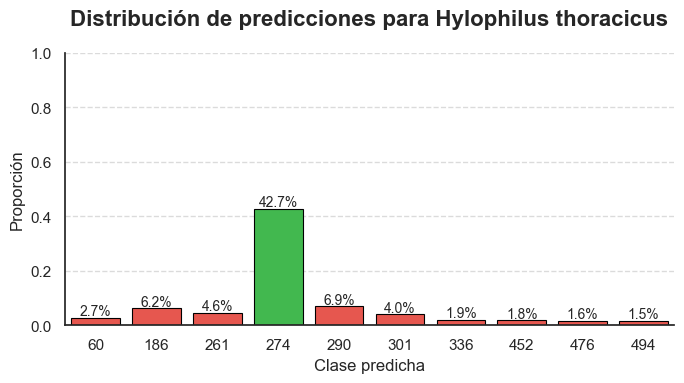

In [53]:
plot_incertidumbres(Hylophilus_thoracicus, 274, "Hylophilus thoracicus")

/var/folders/_1/9ctwy_pn6bv2hyw11l_gqhm9855lbl/T/ipykernel_26938/3535191964.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


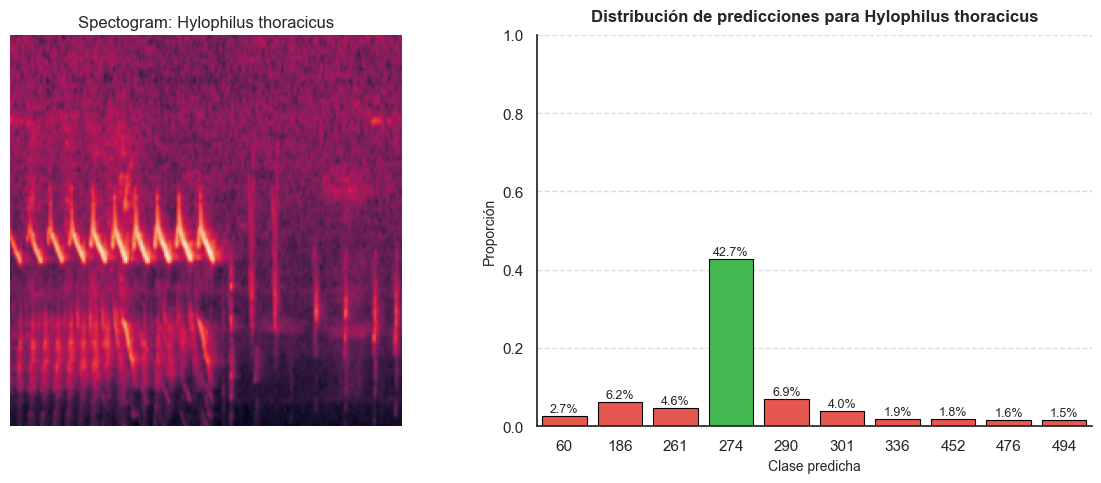

In [98]:
plot_combinado(
    ruta_imagen=sp['image_path'].iloc[0],
    especie_df=Hylophilus_thoracicus,
    label=274,
    titulo_especie="Hylophilus thoracicus"
)

# **Mimus gilvus**

In [99]:
sp = data[data["label"] == "Mimus gilvus"]
muestra = sp[sp['image_path'].str.contains('40536_5.jpeg')]
muestra

,label,image_path
16615,Mimus gilvus,src/data/images_test/images_spectograms/Mimus gilvus/40536_5.jpeg


In [75]:
df_final = crear_dataframe_incertidumbre(data, muestra, model)
df_final.head()

Especies procesadas:   0%|          | 0/1 [00:00<?, ?it/s]


Especie 1 de 1, (Mimus gilvus)


Especies procesadas:   0%|          | 0/1 [17:44<?, ?it/s]
2025-04-21 20:27:30.862059: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
Especies procesadas: 100%|██████████| 1/1 [06:09<00:00, 369.89s/it]


,especie,clase_real,clase_predicha,prediccion_mc,confianza_mc,true_positive,true_positivo_mc,entropia
0,Mimus gilvus,338,427,347,0.01,0,0,6.45
1,Mimus gilvus,338,427,452,0.00,0,0,6.45
2,Mimus gilvus,338,427,60,0.00,0,0,6.45
3,Mimus gilvus,338,427,195,0.00,0,0,6.45
4,Mimus gilvus,338,427,452,0.01,0,0,6.45


In [76]:
Mimus_gilvus = df_final['prediccion_mc'].\
    value_counts(normalize=True).reset_index().\
    sort_values(by='proportion', ascending=False).head(10)

In [77]:
Mimus_gilvus

,prediccion_mc,proportion
0,636,0.14
1,495,0.10
2,640,0.08
3,494,0.07
4,544,0.07
5,338,0.06
6,621,0.06
7,666,0.04
8,316,0.04
9,65,0.03


/var/folders/_1/9ctwy_pn6bv2hyw11l_gqhm9855lbl/T/ipykernel_26938/3577632967.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


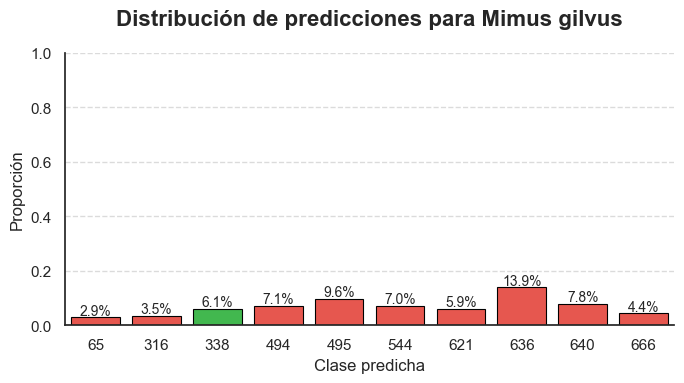

In [100]:
plot_incertidumbres(Mimus_gilvus, 338, "Mimus gilvus")

/var/folders/_1/9ctwy_pn6bv2hyw11l_gqhm9855lbl/T/ipykernel_26938/3535191964.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


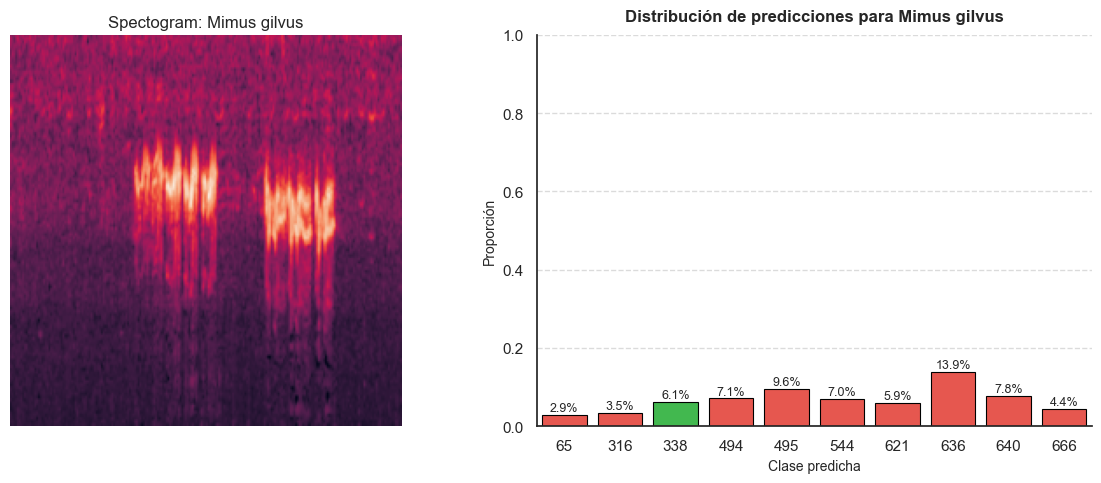

In [122]:
plot_combinado(
    ruta_imagen=sp['image_path'].iloc[20],
    especie_df=Mimus_gilvus,
    label=338,
    titulo_especie="Mimus gilvus"
)

# **Lathrotriccus euleri**

In [123]:
sp = data[data["label"] == "Lathrotriccus euleri"]
muestra = sp[sp['image_path'].str.contains('123104_4.jpeg')]
muestra

,label,image_path
14676,Lathrotriccus euleri,src/data/images_test/images_spectograms/Lathrotriccus euleri/123104_4.jpeg


In [124]:
df_final = crear_dataframe_incertidumbre(data, muestra, model)
df_final.head()

Especies procesadas:   0%|          | 0/1 [00:00<?, ?it/s]


Especie 1 de 1, (Lathrotriccus euleri)


Especies procesadas: 100%|██████████| 1/1 [06:18<00:00, 378.13s/it]


,especie,clase_real,clase_predicha,prediccion_mc,confianza_mc,true_positive,true_positivo_mc,entropia
0,Lathrotriccus euleri,300,299,261,0.01,0,0,6.46
1,Lathrotriccus euleri,300,299,277,0.00,0,0,6.46
2,Lathrotriccus euleri,300,299,277,0.01,0,0,6.46
3,Lathrotriccus euleri,300,299,300,0.00,0,1,6.46
4,Lathrotriccus euleri,300,299,300,0.01,0,1,6.46


In [125]:
Lathrotriccus_euleri = df_final['prediccion_mc'].\
    value_counts(normalize=True).reset_index().\
    sort_values(by='proportion', ascending=False).head(10)

In [126]:
Lathrotriccus_euleri

,prediccion_mc,proportion
0,300,0.29
1,277,0.21
2,51,0.04
3,261,0.04
4,641,0.04
5,370,0.03
6,249,0.03
7,658,0.02
8,240,0.02
9,608,0.02


/var/folders/_1/9ctwy_pn6bv2hyw11l_gqhm9855lbl/T/ipykernel_26938/3577632967.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


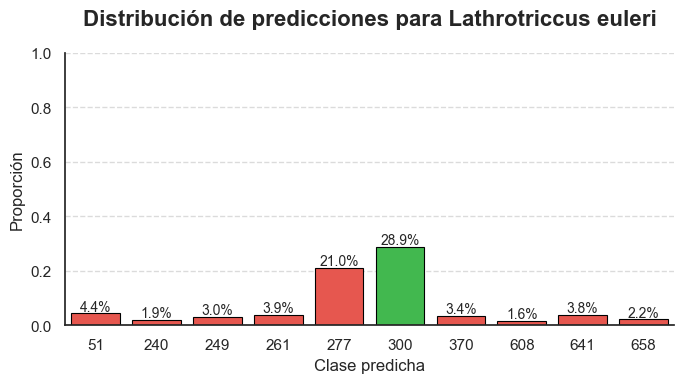

In [127]:
plot_incertidumbres(Lathrotriccus_euleri, 300, "Lathrotriccus euleri")

/var/folders/_1/9ctwy_pn6bv2hyw11l_gqhm9855lbl/T/ipykernel_26938/3535191964.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


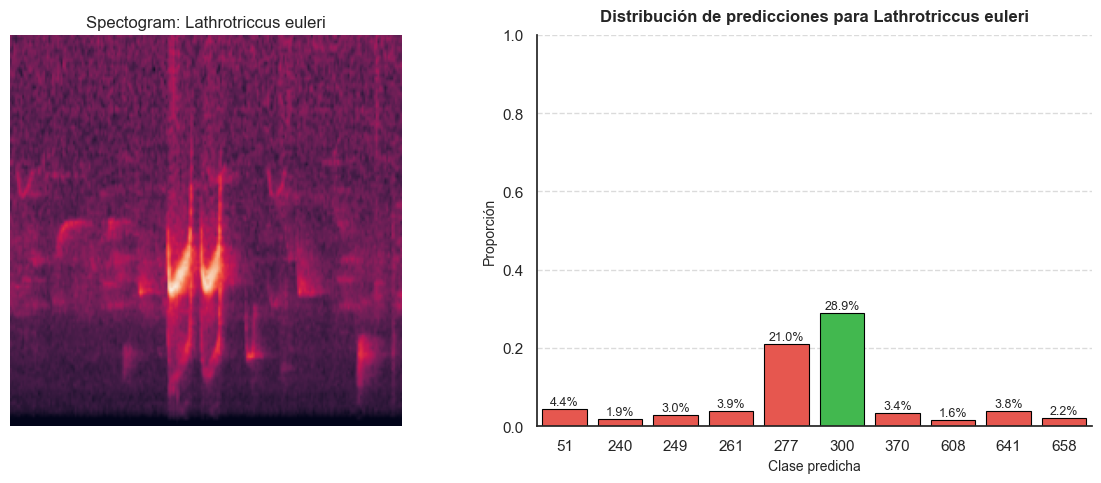

In [128]:
plot_combinado(
    ruta_imagen=sp['image_path'].iloc[20],
    especie_df=Lathrotriccus_euleri,
    label=300,
    titulo_especie="Lathrotriccus euleri"
)

## **Tests**

In [40]:
sp = data[data["label"] == "Lathrotriccus euleri"]

In [ ]:
for i in range(len(sp)):
    path = sp['image_path'].iloc[i].split("/")[5]
    muestra = sp[sp['image_path'].str.contains(path)]
    df_final = crear_dataframe_incertidumbre(data, muestra, model)
    print(df_final)

* Calcular la moda
* Calcular la distribución

In [18]:
import pandas as pd
df = pd.read_csv("src/data/incertidumbres_ResNet152V2.csv")

In [19]:
df = df.groupby('especie').agg(
    {
        'registros': 'sum',
        'true_positive': 'mean',
        'true_positivo_mc': 'mean',
        'confianza_mc': 'max',

    }
).reset_index()

In [ ]:
df.sort_values(by='true_positivo_mc', ascending=False)